Import packages and Datasets
---

In [53]:
import sys
import os
import tifffile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
sys.path.append('/home/cyf/wbi/Virginia/code_for_paper/wholistic_registration/src/wholistic_registration')
current_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.dirname(current_dir)
sys.path.append(root_dir)
fig_root=Path("/home/cyf/wbi/Virginia/code_for_paper/Fig2")
root_dir = Path('/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos')
from utils import simulation

# CoarseFlow imports — need both parent (for CoarseFlow package) and CoarseFlow itself (for internal "from models.xxx" imports)
sys.path.insert(0, '/home/cyf/wbi/Virginia/code_for_paper')
sys.path.insert(0, '/home/cyf/wbi/Virginia/code_for_paper/CoarseFlow')
from CoarseFlow.training.inference import (
    load_coarseflow_model_from_pth,
    percentile_normalize_01_np,
    get_device,
)

zslices = [2, 10, 18] 
experiment_groups = ['art_R', 'amp', 'noise_level']  
results = {} 
results = {group: {} for group in experiment_groups}
repo_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir() and d.name.startswith('rep')])
num_repos = len(repo_dirs)
print(f"Found {num_repos} repos: {[d.name for d in repo_dirs]}")
print(f"Device: {get_device()}")

Found 10 repos: ['rep01', 'rep02', 'rep03', 'rep04', 'rep05', 'rep06', 'rep07', 'rep08', 'rep09', 'rep10']
Device: cuda


Import model
---

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
pth_path = "/home/cyf/wbi/Virginia/code_for_paper/CoarseFlow/coarseflow_swin3d_v3_stage3_residual/best.pth"
device = get_device()

model, model_config, ckpt, load_msg = load_coarseflow_model_from_pth(
    pth_path=pth_path,
    model_module="CoarseFlow.models.SparseGMFlow3D",
    model_class="CoarseMatchingNet",
    device=device,
)
print(f"Model loaded from: {pth_path}")
print(f"control_stride={model_config['control_stride']}, encoder_stride={model_config['encoder_stride']}")
print(f"num_refine_iters={model_config['num_refine_iters']}")
print(f"Load message: {load_msg}")

Model loaded from: /home/cyf/wbi/Virginia/code_for_paper/CoarseFlow/coarseflow_swin3d_v3_stage3_residual/best.pth
control_stride=16, encoder_stride=8
num_refine_iters=2
Load message: <All keys matched successfully>


Inference Functions
---

In [3]:
@torch.no_grad()
def run_inference_one_sample(mov_path, ref_path, z_init, device, model, normalize=True):
    """
    Run CoarseFlow inference on a single data sample.

    Args:
        mov_path: path to mov.tif, shape (H, W, K_full)
        ref_path: path to ref.tif, shape (H, W, D)
        z_init: list of z-slice indices to select from mov, also used as initial z positions
        device: torch device
        model: loaded CoarseMatchingNet
        normalize: whether to apply percentile normalization

    Returns:
        dict with keys: pred_coords (K,Hc,Wc,3), pred_disp (K,Hc,Wc,3), coords0 (K,Hc,Wc,3)
    """
    # ---- Read data — stored as (H, W, K) and (H, W, D) ----
    mov_full = tifffile.imread(str(mov_path))   # (H, W, K_full)
    ref_full = tifffile.imread(str(ref_path))   # (H, W, D)

    # Select moving slices by z_init, transpose to zyx: (K, H, W) and (D, H, W)
    z_init_list = [int(z) for z in z_init]
    mov_zyx = mov_full[..., z_init_list].transpose(2, 0, 1).astype(np.float32)  # (K, H, W)
    ref_zyx = ref_full.transpose(2, 0, 1).astype(np.float32)                     # (D, H, W)

    if normalize:
        mov_zyx = percentile_normalize_01_np(mov_zyx)
        ref_zyx = percentile_normalize_01_np(ref_zyx)

    z_init_np = np.array(z_init, dtype=np.float32)

    # ---- Model forward ----
    mov_t = torch.from_numpy(mov_zyx).float().to(device)[None, None]   # (1,1,K,H,W)
    ref_t = torch.from_numpy(ref_zyx).float().to(device)[None, None]   # (1,1,D,H,W)
    z_init_t = torch.from_numpy(z_init_np).float().to(device)[None]     # (1,K)

    with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
        outputs = model(mov_t, ref_t, z_init=z_init_t)

    pred_coords = outputs["pred_coords"][0].cpu().numpy()  # (K, Hc, Wc, 3) zyx
    pred_disp   = outputs["pred_disp"][0].cpu().numpy()    # (K, Hc, Wc, 3) zyx
    coords0     = outputs["coords0"][0].cpu().numpy()      # (K, Hc, Wc, 3) zyx

    return {
        "pred_coords": pred_coords,
        "pred_disp": pred_disp,
        "coords0": coords0,
    }

Batch Inference over All Repos
---

In [ ]:
output_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/network_prediction')
output_root.mkdir(parents=True, exist_ok=True)

z_init = zslices  # [2, 10, 18]

# Count total samples
total = 0
for repo_dir in repo_dirs:
    for group in experiment_groups:
        group_dir = repo_dir / group
        if not group_dir.exists():
            continue
        for subfolder in group_dir.iterdir():
            if subfolder.is_dir():
                total += 1

print(f"Total samples to process: {total}")
print(f"Output directory: {output_root}")

count = 0
for repo_dir in repo_dirs:
    repo_name = repo_dir.name
    print(f"\n{'='*60}")
    print(f"Processing {repo_name}")
    print(f"{'='*60}")
    
    for group in experiment_groups:
        group_dir = repo_dir / group
        if not group_dir.exists():
            print(f"  {group}: directory not found, skipping")
            continue
        
        for subfolder in sorted(group_dir.iterdir(), key=lambda x: int(x.name)):
            if not subfolder.is_dir():
                continue
            
            exp_level = subfolder.name
            mov_path = subfolder / 'mov.tif'
            ref_path = subfolder / 'ref.tif'
            
            if not mov_path.exists() or not ref_path.exists():
                print(f"  [{count+1}/{total}] {group}/{exp_level}: missing files, skipping")
                count += 1
                continue
            
            count += 1
            print(f"  [{count}/{total}] {group}/{exp_level}...", end=" ", flush=True)
            
            try:
                result = run_inference_one_sample(
                    mov_path=str(mov_path),
                    ref_path=str(ref_path),
                    z_init=z_init,
                    device=device,
                    model=model,
                )
                
                # Save prediction results
                save_dir = output_root / repo_name / group / exp_level
                save_dir.mkdir(parents=True, exist_ok=True)
                np.save(save_dir / 'pred_coords.npy', result['pred_coords'])
                np.save(save_dir / 'pred_disp.npy', result['pred_disp'])
                np.save(save_dir / 'coords0.npy', result['coords0'])
                
                print(f"ok  shape={result['pred_coords'].shape}")
                
            except Exception as e:
                print(f"FAILED: {e}")
                import traceback
                traceback.print_exc()

print(f"\n{'='*60}")
print(f"All done! {count} samples processed.")
print(f"Results saved to: {output_root}")

Total samples to process: 290
Output directory: /home/cyf/wbi/Virginia/code_for_paper/data/network_prediction

Processing rep01
  [1/290] art_R/1... ok  shape=(3, 72, 72, 3)
  [2/290] art_R/2... ok  shape=(3, 72, 72, 3)
  [3/290] art_R/3... ok  shape=(3, 72, 72, 3)
  [4/290] art_R/4... ok  shape=(3, 72, 72, 3)
  [5/290] art_R/5... ok  shape=(3, 72, 72, 3)
  [6/290] art_R/6... ok  shape=(3, 72, 72, 3)
  [7/290] art_R/7... ok  shape=(3, 72, 72, 3)
  [8/290] art_R/8... ok  shape=(3, 72, 72, 3)
  [9/290] art_R/9... ok  shape=(3, 72, 72, 3)
  [10/290] art_R/10... ok  shape=(3, 72, 72, 3)
  [11/290] amp/1... ok  shape=(3, 72, 72, 3)
  [12/290] amp/2... ok  shape=(3, 72, 72, 3)
  [13/290] amp/3... ok  shape=(3, 72, 72, 3)
  [14/290] amp/4... ok  shape=(3, 72, 72, 3)
  [15/290] amp/5... ok  shape=(3, 72, 72, 3)
  [16/290] amp/6... ok  shape=(3, 72, 72, 3)
  [17/290] amp/7... ok  shape=(3, 72, 72, 3)
  [18/290] amp/8... ok  shape=(3, 72, 72, 3)
  [19/290] amp/9... ok  shape=(3, 72, 72, 3)
  [20

Metrics Computation\n---\n\nLoad saved predictions and compute MSE/SSIM against raw data.

In [24]:
# ============================================================
# Metrics Computation
# ============================================================
# Load saved pred_coords/pred_disp, compute 4 sets of MSE/SSIM:
#   1. init:        mov vs ref[z_init] (no registration)
#   2. pred:        mov vs ref sampled at model pred_coords
#   3. wbi:         mov vs ref after iterative WBI from scratch
#   4. model_wbi:   mov vs ref after iterative WBI initialised with model's predicted motion
#                   (phase = identity from z_init, motion = model's dense displacement)
# ============================================================

import csv
import cupy as cp
import pandas as pd
import torch.nn.functional as F
from CoarseFlow.training.inference import (
    control_coords_to_dense_phase_torch,
    sample_ref_by_phase_np,
)
from utils.simulation import compute_intensity_mse, compute_volume_ssim
from utils import calFlowCrossResolution

# CuPy for WBI (same GPU as PyTorch)
cp.cuda.Device(0).use()

pred_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/network_prediction')
data_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos')
z_init = zslices  # [2, 10, 18]
control_stride = model_config['control_stride']

print(f"Prediction root: {pred_root}")
print(f"Data root: {data_root}")
print(f"z_init: {z_init}, control_stride: {control_stride}")


# ---- Convert model pred_disp (control points, zyx) to dense motion (H,W,K,3, xyz) ----
def pred_disp_to_dense_motion(pred_disp, K, H, W, control_stride, device):
    """
    Convert model's pred_disp from control-point grid to dense motion field
    in the format expected by getMotion_v2.

    Args:
        pred_disp: (K, Hc, Wc, 3) zyx order, control-point displacement
        K, H, W: original moving image dimensions
        control_stride: model's control stride

    Returns:
        dense_motion: (H, W, K, 3) xyz order, float32 numpy
    """
    Hc, Wc = pred_disp.shape[1], pred_disp.shape[2]

    # (K, Hc, Wc, 3) zyx -> (K, 3, Hc, Wc)
    disp_t = torch.from_numpy(pred_disp).float().to(device)
    disp_t = disp_t.permute(0, 3, 1, 2).contiguous()  # (K, 3, Hc, Wc)

    # Build dense grid
    y_dense = torch.arange(H, device=device, dtype=torch.float32)
    x_dense = torch.arange(W, device=device, dtype=torch.float32)
    yy, xx = torch.meshgrid(y_dense, x_dense, indexing='ij')  # (H, W)

    yy_ctrl = yy / float(control_stride)
    xx_ctrl = xx / float(control_stride)

    yy_norm = 2.0 * yy_ctrl / float(Hc - 1) - 1.0 if Hc > 1 else torch.zeros_like(yy_ctrl)
    xx_norm = 2.0 * xx_ctrl / float(Wc - 1) - 1.0 if Wc > 1 else torch.zeros_like(xx_ctrl)

    grid = torch.stack([xx_norm, yy_norm], dim=-1)  # (H, W, 2)
    grid = grid[None].expand(K, H, W, 2).contiguous()  # (K, H, W, 2)

    # grid_sample expects (N, C, H_in, W_in) input and (N, H_out, W_out, 2) grid
    disp_dense = F.grid_sample(
        disp_t, grid, mode='bilinear', padding_mode='border', align_corners=True,
    )  # (K, 3, H, W)

    disp_dense = disp_dense.permute(0, 2, 3, 1).contiguous()  # (K, H, W, 3) zyx

    # zyx -> xyz: [dz, dy, dx] -> [dx, dy, dz]
    dense_motion_xyz = disp_dense[..., [2, 1, 0]]  # (K, H, W, 3) xyz

    # (K, H, W, 3) -> (X, Y, K, 3) for getMotion_v2
    dense_motion = dense_motion_xyz.permute(2, 1, 0, 3).cpu().numpy()  # (X, Y, K, 3) xyz
    return dense_motion.astype(np.float32, copy=False)


# ---- WBI refinement helper ----
def run_wbi_refine(mov_zyx, ref_zyx, init_phase_xyz, init_motion=None,
                   zRatio=3.0769230769230766*8, zRatio_HR=3.0769230769230766,
                   layer=1, n_iter=15, r=5, smoothPenalty=0.1):
    """
    Run iterative WBI refinement (getMotion_v2).

    Args:
        mov_zyx:        (K, H, W) float32, raw moving slices
        ref_zyx:        (D, H, W) float32, raw reference volume
        init_phase_xyz: (K, H, W, 3) float32, initial dense phase in xyz order
        init_motion:    (X, Y, K, 3) float32 or None, initial motion in xyz order
                         If provided, used as the starting motion for getMotion_v2.

    Returns:
        mapped_zyx: (K, H, W) float32, reference warped by refined phase
    """
    K, H, W = mov_zyx.shape
    D = ref_zyx.shape[0]

    # Convert to getMotion_v2 format: (H, W, K) / (H, W, D) / (H, W, K, 3)
    mov_hwk = np.ascontiguousarray(mov_zyx.transpose(2, 1, 0).astype(np.float32))  # (W,H,K) wait...
    # Actually, getMotion_v2 expects (H, W, D_mov). 
    # mov_zyx is (K, H, W) = (K, Y, X). We need (H, W, K) = (Y, X, K).
    # transpose(1, 2, 0): (K, H, W) -> (H, W, K)
    mov_for_wbi = np.ascontiguousarray(mov_zyx.transpose(2, 1, 0).astype(np.float32))  # (X, Y, K)
    ref_for_wbi = np.ascontiguousarray(ref_zyx.transpose(2, 1, 0).astype(np.float32))  # (X, Y, D)

    # init_phase_xyz: (K, H, W, 3) -> (H, W, K, 3)
    init_phase_xyk_xyz = np.ascontiguousarray(
        init_phase_xyz.transpose(2, 1, 0, 3).astype(np.float32)
    )  # (X, Y, K, 3) xyz

    option = {
        'phase': init_phase_xyk_xyz,
        'zRatio': zRatio,
        'zRatio_HR': zRatio_HR,
        'layer': layer,
        'iter': n_iter,
        'r': r,
        'smoothPenalty': smoothPenalty,
        'movRange': 5.0,
        'tol': 1e-6,
        'wrong_region_enable': False,
        'mask_ref': np.zeros(ref_for_wbi.shape, dtype=np.bool_),
        'mask_mov': np.zeros(mov_for_wbi.shape, dtype=np.bool_),
    }

    if init_motion is not None:
        # init_motion expected shape: (H, W, K, 3) xyz, matching mov_for_wbi shape
        option['motion'] = np.ascontiguousarray(init_motion.astype(np.float32))

    phase_new, motion_current, mapped_xyk = calFlowCrossResolution.getMotion_v2(
        mov_for_wbi, ref_for_wbi, option, verbose=False,
    )

    # mapped_xyk: (X, Y, K) -> back to (K, Y, X) = (K, H, W)
    mapped_zyx = mapped_xyk.transpose(2, 1, 0).astype(np.float32, copy=False)  # (K, H, W)
    return mapped_zyx


# ---- Helper to build identity phase from z_init ----
def make_init_phase_xyz_from_z_init(z_init, image_shape_yx):
    """Build identity XY + initial Z phase in xyz order."""
    z_init = np.asarray(z_init, dtype=np.float32).reshape(-1)
    K = len(z_init)
    H, W = image_shape_yx
    yy, xx = np.meshgrid(
        np.arange(H, dtype=np.float32),
        np.arange(W, dtype=np.float32),
        indexing="ij",
    )
    phase = np.zeros((K, H, W, 3), dtype=np.float32)
    phase[..., 0] = xx[None, :, :]
    phase[..., 1] = yy[None, :, :]
    phase[..., 2] = z_init[:, None, None]
    return phase


# ---- Helper to compute all metrics for one sample ----
@torch.no_grad()
def compute_metrics_one_sample(pred_coords_path, mov_path, ref_path, z_init, device, control_stride):
    """
    Load saved pred_coords + pred_disp and compute 4 sets of MSE/SSIM.
    """
    # Load predictions
    pred_dir = Path(pred_coords_path).parent
    pred_coords = np.load(pred_coords_path)                # (K, Hc, Wc, 3) zyx
    pred_disp   = np.load(pred_dir / 'pred_disp.npy')      # (K, Hc, Wc, 3) zyx

    # Load raw data
    mov_full = tifffile.imread(str(mov_path))
    ref_full = tifffile.imread(str(ref_path))

    z_init_list = [int(z) for z in z_init]
    mov_zyx_raw = mov_full[..., z_init_list].transpose(2, 0, 1).astype(np.float32)  # (K, H, W)
    ref_zyx_raw = ref_full.transpose(2, 0, 1).astype(np.float32)                      # (D, H, W)

    K, H, W = mov_zyx_raw.shape
    z_init_np = np.array(z_init, dtype=np.float32)

    result = {}

    # ---- 1. Init: mov vs ref[z_init] ----
    ref_init_slices = ref_zyx_raw[z_init_list]
    result['mse_init'] = compute_intensity_mse(mov_zyx_raw, ref_init_slices)
    result['ssim_init'] = compute_volume_ssim(
        mov_zyx_raw.transpose(1, 2, 0),
        ref_init_slices.transpose(1, 2, 0),
    )

    # ---- 2. Pred: mov vs ref sampled at model pred_coords ----
    pred_phase_xyz = control_coords_to_dense_phase_torch(
        pred_coords_zyx=pred_coords,
        z_init=z_init_np,
        image_shape_yx=(H, W),
        control_stride=control_stride,
        phase_order='xyz',
        device=device,
    )  # (K, H, W, 3) xyz

    pred_warped_zyx = sample_ref_by_phase_np(ref_zyx_raw, pred_phase_xyz, device=device)
    result['mse_pred'] = compute_intensity_mse(mov_zyx_raw, pred_warped_zyx)
    result['ssim_pred'] = compute_volume_ssim(
        mov_zyx_raw.transpose(1, 2, 0),
        pred_warped_zyx.transpose(1, 2, 0),
    )

    # ---- 3. WBI-only: iterative from identity phase, no initial motion ----
    init_phase_xyz = make_init_phase_xyz_from_z_init(z_init_np, (H, W))
    mapped_wbi_zyx = run_wbi_refine(mov_zyx_raw, ref_zyx_raw, init_phase_xyz)
    result['mse_wbi'] = compute_intensity_mse(mov_zyx_raw, mapped_wbi_zyx)
    result['ssim_wbi'] = compute_volume_ssim(
        mov_zyx_raw.transpose(1, 2, 0),
        mapped_wbi_zyx.transpose(1, 2, 0),
    )

    # ---- 4. Model+WBI: identity phase + model's pred_disp as initial motion ----
    dense_motion = pred_disp_to_dense_motion(pred_disp, K, H, W, control_stride, device)
    mapped_model_wbi_zyx = run_wbi_refine(
        mov_zyx_raw, ref_zyx_raw, init_phase_xyz,
        init_motion=dense_motion,  # model's displacement as starting motion
    )
    result['mse_model_wbi'] = compute_intensity_mse(mov_zyx_raw, mapped_model_wbi_zyx)
    result['ssim_model_wbi'] = compute_volume_ssim(
        mov_zyx_raw.transpose(1, 2, 0),
        mapped_model_wbi_zyx.transpose(1, 2, 0),
    )

    return result


# ---- Iterate over all saved predictions and compute metrics ----
metrics_all = []
total = 0
for repo_dir in sorted(pred_root.iterdir()):
    if not repo_dir.is_dir():
        continue
    for group_dir in sorted(repo_dir.iterdir()):
        if not group_dir.is_dir():
            continue
        for level_dir in sorted(group_dir.iterdir()):
            if level_dir.is_dir() and (level_dir / 'pred_coords.npy').exists():
                total += 1

print(f"\nTotal prediction results found: {total}")
print("(WBI refinement runs getMotion_v2 per sample)\n")

count = 0
for repo_dir in sorted(pred_root.iterdir()):
    if not repo_dir.is_dir():
        continue
    repo_name = repo_dir.name

    for group_dir in sorted(repo_dir.iterdir()):
        if not group_dir.is_dir():
            continue
        group = group_dir.name

        for level_dir in sorted(group_dir.iterdir(), key=lambda x: int(x.name)):
            if not level_dir.is_dir():
                continue
            exp_level = level_dir.name

            pred_path = level_dir / 'pred_coords.npy'
            if not pred_path.exists():
                continue

            mov_path = data_root / repo_name / group / exp_level / 'mov.tif'
            ref_path = data_root / repo_name / group / exp_level / 'ref.tif'

            if not mov_path.exists() or not ref_path.exists():
                print(f"  [{count+1}/{total}] {repo_name}/{group}/{exp_level}: raw data missing, skipping")
                count += 1
                continue

            count += 1
            print(f"  [{count}/{total}] {repo_name}/{group}/{exp_level}...", end=" ", flush=True)

            try:
                metrics = compute_metrics_one_sample(
                    pred_coords_path=str(pred_path),
                    mov_path=str(mov_path),
                    ref_path=str(ref_path),
                    z_init=z_init,
                    device=device,
                    control_stride=control_stride,
                )

                metrics['repo'] = repo_name
                metrics['group'] = group
                metrics['level'] = exp_level
                metrics_all.append(metrics)

                print(f"ok  "
                      f"init={metrics['mse_init']:.1f}/{metrics['ssim_init']:.4f}  "
                      f"pred={metrics['mse_pred']:.1f}/{metrics['ssim_pred']:.4f}  "
                      f"wbi={metrics['mse_wbi']:.1f}/{metrics['ssim_wbi']:.4f}  "
                      f"m+wbi={metrics['mse_model_wbi']:.1f}/{metrics['ssim_model_wbi']:.4f}")

            except Exception as e:
                print(f"FAILED: {e}")
                import traceback
                traceback.print_exc()

# ---- Save metrics summary CSV ----
fieldnames = ['repo', 'group', 'level',
              'mse_init', 'ssim_init', 'mse_pred', 'ssim_pred',
              'mse_wbi', 'ssim_wbi', 'mse_model_wbi', 'ssim_model_wbi']
metrics_path = pred_root / 'metrics_summary.csv'
with open(metrics_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(metrics_all)

print(f"\nMetrics saved to: {metrics_path}")

# ---- Print grouped summary ----
if metrics_all:
    print(f"\n{'='*75}")
    print("Summary by experiment group (mean ± std)")
    print(f"{'='*75}")
    df = pd.DataFrame(metrics_all)
    for group in experiment_groups:
        sub = df[df['group'] == group]
        if len(sub) > 0:
            print(f"\n{group} ({len(sub)} samples):")
            print(f"  {'Method':<12} {'MSE':>14} {'SSIM':>10}")
            print(f"  {'-'*26}")
            baseline = sub['mse_init'].mean()
            for method, mse_col, ssim_col in [
                ("init", "mse_init", "ssim_init"),
                ("pred", "mse_pred", "ssim_pred"),
                ("wbi", "mse_wbi", "ssim_wbi"),
                ("model+wbi", "mse_model_wbi", "ssim_model_wbi"),
            ]:
                m_mse, s_mse = sub[mse_col].mean(), sub[mse_col].std()
                m_ssim, s_ssim = sub[ssim_col].mean(), sub[ssim_col].std()
                delta = (baseline - m_mse) / baseline * 100
                print(f"  {method:<12} {m_mse:>8.2f}±{s_mse:<7.2f} {m_ssim:>6.4f}±{s_ssim:.4f}  (ΔMSE {delta:+.1f}%)")

print(f"\nDone! {len(metrics_all)} samples evaluated.")

Prediction root: /home/cyf/wbi/Virginia/code_for_paper/data/network_prediction
Data root: /home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos
z_init: [2, 10, 18], control_stride: 16

Total prediction results found: 290
(WBI refinement runs getMotion_v2 per sample)

  [1/290] rep01/amp/1... ok  init=2852.1/0.9557  pred=471.5/0.9857  wbi=168.9/0.9945  m+wbi=144.3/0.9952
  [2/290] rep01/amp/2... ok  init=3346.8/0.9554  pred=510.8/0.9844  wbi=222.8/0.9925  m+wbi=175.4/0.9940
  [3/290] rep01/amp/3... ok  init=3969.7/0.9537  pred=533.4/0.9855  wbi=324.3/0.9898  m+wbi=182.7/0.9943
  [4/290] rep01/amp/4... ok  init=3314.9/0.9535  pred=519.5/0.9864  wbi=376.3/0.9894  m+wbi=188.4/0.9947
  [5/290] rep01/amp/5... ok  init=3016.8/0.9533  pred=574.8/0.9778  wbi=414.3/0.9821  m+wbi=169.9/0.9927
  [6/290] rep01/amp/6... ok  init=3811.6/0.9522  pred=753.0/0.9831  wbi=471.6/0.9856  m+wbi=225.5/0.9929
  [7/290] rep01/amp/7... ok  init=5595.9/0.9480  pred=643.2/0.9842  wbi=828.5/0.9851  m+wb

Ablation Box Plots
---

Compare model improvement ratios with and without WBI refinement.

Loaded 290 samples (pooled across all experiment groups)


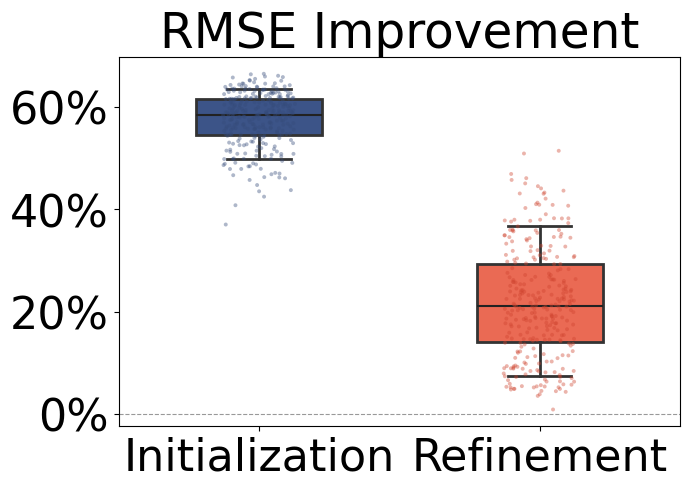

RMSE boxplot saved to: /home/cyf/wbi/Virginia/code_for_paper/Fig2/ablation_boxplot_rmse.pdf


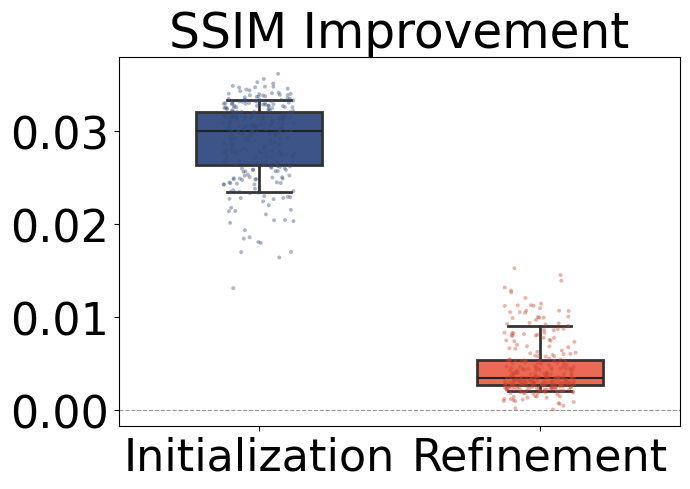

SSIM boxplot saved to: /home/cyf/wbi/Virginia/code_for_paper/Fig2/ablation_boxplot_ssim.pdf

RMSE y-limits (auto): -0.024 to 0.698

  Model vs Init (n=290):
    whiskers: [+44.7%, +66.5%]
    data min=+37.0%  max=+66.5%
    Q1=+54.6%  median=+58.4%  Q3=+61.6%  IQR=+7.0%
    mean ± std: +57.5% ± +5.2%

  Model+WBI vs WBI (n=290):
    whiskers: [+0.9%, +51.4%]
    data min=+0.9%  max=+51.4%
    Q1=+14.0%  median=+21.0%  Q3=+29.3%  IQR=+15.3%
    mean ± std: +21.7% ± +10.8%

SSIM y-limits (auto): -0.0017 to 0.0380

  Model vs Init (n=290):
    whiskers: [+0.0180, +0.0362]
    data min=+0.0131  max=+0.0362
    Q1=+0.0264  median=+0.0300  Q3=+0.0321  IQR=+0.0057
    mean ± std: +0.0290 ± +0.0041

  Model+WBI vs WBI (n=290):
    whiskers: [+0.0001, +0.0093]
    data min=+0.0001  max=+0.0153
    Q1=+0.0027  median=+0.0035  Q3=+0.0054  IQR=+0.0027
    mean ± std: +0.0045 ± +0.0029

To manually set y-limits, edit YLIM_RMSE / YLIM_SSIM at the top of this cell.


In [58]:
# ============================================================
# Ablation Box Plots with Scatter
# ============================================================
# Pool all experiment groups together.
# Figure A (RMSE):  Model-vs-Init  vs  Model+WBI-vs-WBI
# Figure B (SSIM):  Model-vs-Init  vs  Model+WBI-vs-WBI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# ================================================================
# ==== USER-ADJUSTABLE PARAMETERS — change these as needed ========
# ================================================================

# --- Figure size ---
FIG_W, FIG_H = 7, 5          # width, height in inches (per figure)

# --- Box colors (fill) ---
BOX_MODEL     = '#3C5488'    # "Model vs Init" box fill (soft blue)
BOX_MODEL_WBI =  "#EA6A54"    # "Model+WBI vs WBI" box fill (soft orange)
BOX_ALPHA     = 1         # box fill transparency
BOX_LW        = 2          # box edge & whisker linewidth
BOX_EDGE      = '#333333'    # box edge & whisker color (dark grey, not blue)

# --- Box whiskers ---
# 1.5 = Tukey (Q1-1.5*IQR to Q3+1.5*IQR)
# (10, 90) = 10th to 90th percentile
# (0, 100) or 'range' = min to max
WHIS = (10, 90)

# --- Scatter points ---
SCATTER_MODEL     = '#354B7A'  # "Model vs Init" scatter (deeper blue)
SCATTER_MODEL_WBI = '#CF442F'  # "Model+WBI vs WBI" scatter (deeper orange)""
SCATTER_SIZE      = 8          # dot size
SCATTER_ALPHA     = 0.4       # dot transparency
SCATTER_JITTER    = 0.13       # horizontal jitter width

# --- Median line inside box ---
MEDIAN_COLOR = '#222222'
MEDIAN_LW    = 1.5

# --- Zero reference line ---
ZERO_COLOR   = '#999999'
ZERO_LW      = 0.8
ZERO_STYLE   = '--'

# --- Tick & label sizes ---
TICK_SIZE      = 32
LABEL_SIZE     = 32
TITLE_SIZE     = 35

# --- Axis labels ---
X_LABELS       = ['Initialization', 'Refinement']
Y_LABEL_RMSE   = ''#RMSE improvement ratio
Y_LABEL_SSIM   = ''#SSIM improvement absolute
TITLE_RMSE     = 'RMSE Improvement'
TITLE_SSIM     = 'SSIM Improvement'

# --- Y-axis range (None = auto) ---
YLIM_RMSE      = None
YLIM_SSIM      = None

# --- Output ---
SAVE_RMSE = fig_root / 'ablation_boxplot_rmse.pdf'
SAVE_SSIM = fig_root / 'ablation_boxplot_ssim.pdf'

# ================================================================
# ==== Data loading & metric computation ==========================
# ================================================================

# Re-define in case this cell is run independently
pred_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/network_prediction')
metrics_path = pred_root / 'metrics_summary.csv'
df = pd.read_csv(metrics_path)
print(f"Loaded {len(df)} samples (pooled across all experiment groups)")

for col in ['mse_init', 'mse_pred', 'mse_wbi', 'mse_model_wbi']:
    df['rmse_' + col[4:]] = np.sqrt(df[col])

improve_rmse_model = (df['rmse_init'] - df['rmse_pred']) / df['rmse_init']
improve_ssim_model = df['ssim_pred'] - df['ssim_init']
improve_rmse_wbi   = (df['rmse_wbi'] - df['rmse_model_wbi']) / df['rmse_wbi']
improve_ssim_wbi   = df['ssim_model_wbi'] - df['ssim_wbi']

rmse_data = [improve_rmse_model.values, improve_rmse_wbi.values]
ssim_data = [improve_ssim_model.values, improve_ssim_wbi.values]

# ================================================================
# ==== FIGURE A: RMSE Improvement =================================
# ================================================================

fig_a, ax_a = plt.subplots(figsize=(FIG_W, FIG_H))

# --- Box plots ---
bp_a = ax_a.boxplot(
    rmse_data,
    positions=[0, 1],
    widths=0.45,
    whis=WHIS,
    patch_artist=True,
    # All edge elements in dark grey
    boxprops=dict(facecolor='white', edgecolor=BOX_EDGE, linewidth=BOX_LW),
    whiskerprops=dict(color=BOX_EDGE, linewidth=BOX_LW),
    capprops=dict(color=BOX_EDGE, linewidth=BOX_LW),
    medianprops=dict(color=MEDIAN_COLOR, linewidth=MEDIAN_LW),
    flierprops=dict(marker='none'),  # hide default outliers — we draw scatter instead
)

# Fill box faces with colour
for i, patch in enumerate(bp_a['boxes']):
    color = BOX_MODEL if i == 0 else BOX_MODEL_WBI
    patch.set_facecolor(color)
    patch.set_alpha(BOX_ALPHA)

# --- Scatter (jittered) ---
for i, data in enumerate(rmse_data):
    jitter = np.random.default_rng(42).uniform(-SCATTER_JITTER, SCATTER_JITTER, size=len(data))
    x = np.full_like(data, i, dtype=float) + jitter
    color = SCATTER_MODEL if i == 0 else SCATTER_MODEL_WBI
    ax_a.scatter(x, data, s=SCATTER_SIZE, c=color, alpha=SCATTER_ALPHA,
                 edgecolors='none', zorder=3)

# --- Zero line ---
ax_a.axhline(y=0, color=ZERO_COLOR, linestyle=ZERO_STYLE, linewidth=ZERO_LW, zorder=0.5)

# --- Axis styling ---
ax_a.set_xticks([0, 1])
ax_a.set_xticklabels(X_LABELS, fontsize=TICK_SIZE)
ax_a.set_ylabel(Y_LABEL_RMSE, fontsize=LABEL_SIZE)
ax_a.set_title(TITLE_RMSE, fontsize=TITLE_SIZE)
ax_a.tick_params(axis='y', labelsize=TICK_SIZE)
ax_a.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

if YLIM_RMSE is not None:
    ax_a.set_ylim(YLIM_RMSE)

fig_a.tight_layout()
fig_a.savefig(SAVE_RMSE, bbox_inches='tight')
plt.show()
print(f"RMSE boxplot saved to: {SAVE_RMSE}")

# ================================================================
# ==== FIGURE B: SSIM Improvement =================================
# ================================================================

fig_b, ax_b = plt.subplots(figsize=(FIG_W, FIG_H))

bp_b = ax_b.boxplot(
    ssim_data,
    positions=[0, 1],
    widths=0.45,
    whis=WHIS,
    patch_artist=True,
    boxprops=dict(facecolor='white', edgecolor=BOX_EDGE, linewidth=BOX_LW),
    whiskerprops=dict(color=BOX_EDGE, linewidth=BOX_LW),
    capprops=dict(color=BOX_EDGE, linewidth=BOX_LW),
    medianprops=dict(color=MEDIAN_COLOR, linewidth=MEDIAN_LW),
    flierprops=dict(marker='none'),
)

for i, patch in enumerate(bp_b['boxes']):
    color = BOX_MODEL if i == 0 else BOX_MODEL_WBI
    patch.set_facecolor(color)
    patch.set_alpha(BOX_ALPHA)

for i, data in enumerate(ssim_data):
    jitter = np.random.default_rng(42).uniform(-SCATTER_JITTER, SCATTER_JITTER, size=len(data))
    x = np.full_like(data, i, dtype=float) + jitter
    color = SCATTER_MODEL if i == 0 else SCATTER_MODEL_WBI
    ax_b.scatter(x, data, s=SCATTER_SIZE, c=color, alpha=SCATTER_ALPHA,
                 edgecolors='none', zorder=3)

ax_b.axhline(y=0, color=ZERO_COLOR, linestyle=ZERO_STYLE, linewidth=ZERO_LW, zorder=0.5)

ax_b.set_xticks([0, 1])
ax_b.set_xticklabels(X_LABELS, fontsize=TICK_SIZE)
ax_b.set_ylabel(Y_LABEL_SSIM, fontsize=LABEL_SIZE)
ax_b.set_title(TITLE_SSIM, fontsize=TITLE_SIZE)
ax_b.tick_params(axis='y', labelsize=TICK_SIZE)

if YLIM_SSIM is not None:
    ax_b.set_ylim(YLIM_SSIM)

fig_b.tight_layout()
fig_b.savefig(SAVE_SSIM, bbox_inches='tight')
plt.show()
print(f"SSIM boxplot saved to: {SAVE_SSIM}")

# ================================================================
# ==== Numeric summary ============================================
# ================================================================

def print_stats(name, data, pct=True):
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1
    whisk_lo = np.min(data[data >= q1 - 1.5 * iqr])
    whisk_hi = np.max(data[data <= q3 + 1.5 * iqr])
    fmt = '{:+.1%}' if pct else '{:+.4f}'
    print(f"\n  {name} (n={len(data)}):")
    print(f"    whiskers: [{fmt.format(whisk_lo)}, {fmt.format(whisk_hi)}]")
    print(f"    data min={fmt.format(data.min())}  max={fmt.format(data.max())}")
    print(f"    Q1={fmt.format(q1)}  median={fmt.format(med)}  Q3={fmt.format(q3)}  IQR={fmt.format(iqr)}")
    print(f"    mean ± std: {fmt.format(np.mean(data))} ± {fmt.format(np.std(data))}")

print(f"\n{'='*55}")
print("RMSE y-limits (auto): {:.3f} to {:.3f}".format(*ax_a.get_ylim()))
print_stats('Model vs Init',     improve_rmse_model, pct=True)
print_stats('Model+WBI vs WBI', improve_rmse_wbi,   pct=True)

print(f"\n{'='*55}")
print("SSIM y-limits (auto): {:.4f} to {:.4f}".format(*ax_b.get_ylim()))
print_stats('Model vs Init',     improve_ssim_model, pct=False)
print_stats('Model+WBI vs WBI', improve_ssim_wbi,   pct=False)

print(f"\nTo manually set y-limits, edit YLIM_RMSE / YLIM_SSIM at the top of this cell.")

Draw Figure
---